### Pristine Fe intensities

In [1]:
from pathlib import Path
import sys

import hyperspy.api as hs
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from tqdm import tqdm

sys.path.append("..")
import roi_tools

rng = np.random.default_rng(0)
n_fp = 50
n_pristine_images = 30

metric = "mean_intensity"

configs = {
    "4 Atoms": [(0, -2), (0, 2), (-1, 0), (1, 0)],
    "8 Atoms": [
        (0, -2), (0, 2),
        (-1, -2), (-1, 0), (-1, 2),
        (1, -2), (1, 0), (1, 2),
    ],
    "14 Atoms": [
        (0, -2), (0, 2),
        (-1, -2), (-1, 0), (-1, 2),
        (1, -2), (1, 0), (1, 2),
        (-2, -2), (-2, 0), (-2, 2),
        (2, -2), (2, 0), (2, 2),
    ],
    # "10 Atoms": [
    #     (0, -2), (0, 2),
    #     (-1, -2), (-1, 0), (-1, 2),
    #     (1, -2), (1, 0), (1, 2),
    #     (-2, 0), (2, 0),
    # ],
}


def indexed_files(folder, pattern):
    return sorted(
        folder.glob(pattern),
        key=lambda path: int(path.stem.rsplit("_", 1)[1]),
    )
def mean_selected(files, indices):
    return np.mean(
        np.stack([np.load(files[index]).squeeze() for index in indices]),
        axis=0,
    )

pristine_dir = Path("../data/simulations/pristine_fp")
pristine_files = indexed_files(pristine_dir, "pristine_fp_*.npy")

def random_index_sets(n_available, n_images):
    return np.array([
        np.sort(rng.choice(n_available, n_fp, replace=False))
        for _ in range(n_images)
    ])

pristine_index_sets = random_index_sets(len(pristine_files), n_pristine_images)
pristine_images = [
    mean_selected(pristine_files, indices)
    for indices in tqdm(pristine_index_sets, desc="Building pristine ensembles")
]

print(f"Pristine ensemble images: {len(pristine_images)}")

Building pristine ensembles: 100%|██████████| 30/30 [00:00<00:00, 32.99it/s]

Pristine ensemble images: 30


In [2]:
grid_creator = roi_tools.GridCreator()
intensity_analyzer = roi_tools.IntensityAnalyzer()

pristine_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(pristine_images[0])
)
def analyze(signal, layout):
    grid = grid_creator.process(signal, layout=layout)
    intensities = intensity_analyzer.values(grid, metric=metric)
    relative = {
        name: intensity_analyzer.relative_vicinity(
            grid, offsets=offsets, metric=metric, values=intensities
        )
        for name, offsets in configs.items()
    }
    return grid, relative


pristine_samples = {name: [] for name in configs}
for image in tqdm(pristine_images, desc="Analyzing pristine ensembles"):
    grid, relative = analyze(hs.signals.Signal2D(image), pristine_layout)
    interior_x_mask = np.zeros(grid.shape, dtype=bool)
    interior_x_mask[2:-2, :] = True
    fe_mask = grid.atom_type_mask("Fe") & interior_x_mask
    for name, values in relative.items():
        pristine_samples[name].append(values[fe_mask & np.isfinite(values)])
pristine_intensities = {
    name: np.concatenate(values) for name, values in pristine_samples.items()
}

Analyzing pristine ensembles: 100%|██████████| 30/30 [00:04<00:00,  7.06it/s]


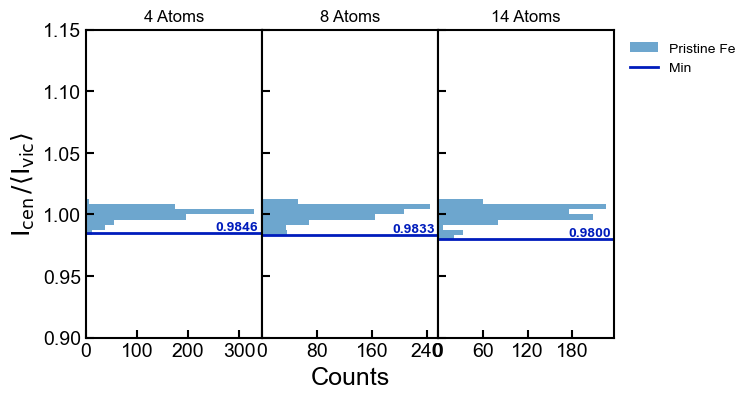

In [3]:
hist_min = 0.9
hist_max = 1.15
n_bins = 60
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "text.usetex": False,
})

fig, axes = plt.subplots(1, len(configs), figsize=(7, 4), sharey=True)

for ax, (name, values) in zip(axes, pristine_intensities.items()):
    mean, std, maximum, minimum = values.mean(), values.std(), values.max(), values.min()
    ax.hist(values, bins=n_bins, range=(hist_min, hist_max), color="#1f77b4", alpha=0.65, orientation="horizontal", label="Pristine Fe")
    # ax.axhspan(mean - std, mean + std, color="#d62728", alpha=0.2)
    # ax.axhline(mean, color="#d62728", linestyle="--", label="Mean")
    # ax.axhline(maximum, color="#001cbc", linewidth=2, label="Max")
    ax.axhline(minimum, color="#001cbc", linewidth=2, label="Min")
    transform = ax.get_yaxis_transform()
    ax.text(0.98, minimum, f"{minimum:.4f}", transform=transform, ha="right", va="bottom", color="#001cbc", fontweight="bold")
    ax.set_title(name)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4, integer=True))
    ax.tick_params(direction="in", length=6)
    ax.set_ylim(hist_min, hist_max)

axes[1].set_xlabel("Counts")
axes[0].set_ylabel(r"$\mathrm{I_{cen}} \, / \langle \mathrm{I_{vic}} \rangle$")
axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(wspace=0, right=0.88)
plt.show()

### Lu_Fe Antisites

In [4]:
n_singlet_images = 10
n_doublet_images = 20
singlet_target = (3, 3)
doublet_target = (4, 3)
layers = np.arange(25)

def defect_files(defect):
    defect_dir = Path("../data/simulations") / defect
    return {
        layer: indexed_files(
            defect_dir / f"{defect}_layer_{layer}",
            f"{defect}_layer_{layer}_ensemble_*.npy",
        )
        for layer in layers
    }


def build_defect_images(files_by_layer, index_sets, description):
    return {
        layer: [mean_selected(files, indices) for indices in index_sets]
        for layer, files in tqdm(files_by_layer.items(), desc=description)
    }


singlet_files = defect_files("LuFe_singlet")
doublet_files = defect_files("LuFe_doublet")
singlet_index_sets = random_index_sets(
    len(singlet_files[layers[0]]), n_singlet_images
)
doublet_index_sets = random_index_sets(
    len(doublet_files[layers[0]]), n_doublet_images
)
singlet_images = build_defect_images(
    singlet_files, singlet_index_sets, "Building LuFe_singlet ensembles"
)
doublet_images = build_defect_images(
    doublet_files, doublet_index_sets, "Building LuFe_doublet ensembles"
)

singlet_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(singlet_images[layers[0]][0])
)
doublet_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(doublet_images[layers[0]][0])
)


def analyze_defect_images(images_by_layer, layout, target, description):
    n_images = len(images_by_layer[layers[0]])
    metrics = {
        name: np.full((len(layers), n_images), np.nan) for name in configs
    }
    with tqdm(total=len(layers) * n_images, desc=description) as progress:
        for layer, images in images_by_layer.items():
            for image_index, image in enumerate(images):
                grid, relative = analyze(hs.signals.Signal2D(image), layout)
                if grid.atom_types[target] != "Fe":
                    raise ValueError(
                        f"Target {target} is not classified as Fe in layer {layer}"
                    )
                for name, values in relative.items():
                    metrics[name][layer, image_index] = values[target]
                progress.update()
    return metrics


singlet_metrics = analyze_defect_images(
    singlet_images, singlet_layout, singlet_target,
    "Analyzing LuFe_singlet ensembles",
)
doublet_metrics = analyze_defect_images(
    doublet_images, doublet_layout, doublet_target,
    "Analyzing LuFe_doublet ensembles",
)
lufe_metrics = {
    name: np.concatenate((singlet_metrics[name], doublet_metrics[name]), axis=1)
    for name in configs
}

print(f"LuFe_singlet images per layer: {len(singlet_index_sets)}")
print(f"LuFe_doublet images per layer: {len(doublet_index_sets)}")

Analyzing LuFe_doublet ensembles: 100%|██████████| 500/500 [00:27<00:00, 18.50it/s]

LuFe_singlet images per layer: 10
LuFe_doublet images per layer: 20


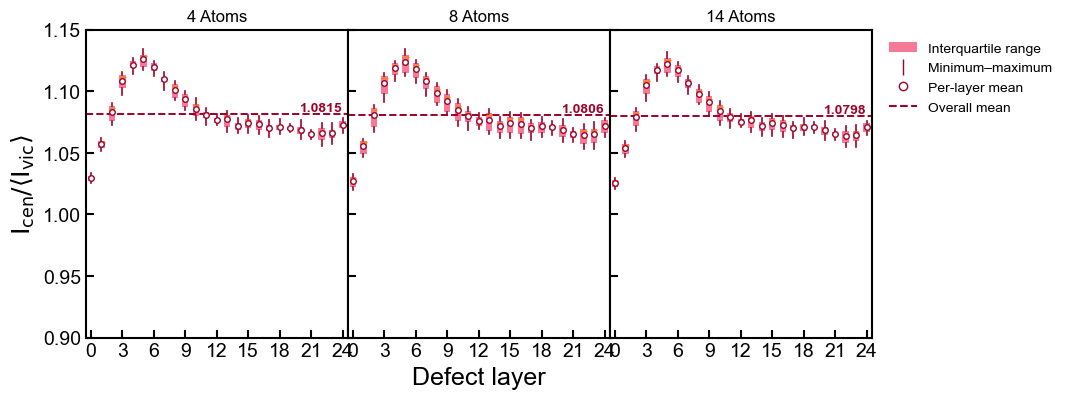

In [16]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

ymin, ymax = 0.9, 1.15
fill, dark = "#F47A98", "#9D0229"

fig, axes = plt.subplots(1, len(lufe_metrics), figsize=(12, 4), sharey=True)

for ax, (name, values) in zip(axes, lufe_metrics.items()):
    mean = np.nanmean(values)

    ax.boxplot(
        values.T,
        positions=layers,
        widths=0.6,
        whis=(0, 100),
        showcaps=False,
        showfliers=False,
        showmeans=True,
        patch_artist=True,
        manage_ticks=False,
        boxprops={"facecolor": fill, "edgecolor": "none"},
        whiskerprops={"color": dark, "linewidth": 1.2},
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": dark,
            "markersize": 4,
        },
    )

    ax.axhline(mean, color=dark, linestyle="--", linewidth=1.4)
    ax.text(
        0.98,
        mean,
        f"{mean:.4f}",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="bottom",
        color=dark,
        fontweight="bold",
    )

    ax.set_title(name)
    ax.set_xlim(min(layers) - 0.5, max(layers) + 0.5)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(direction="in", length=6)

axes[0].set_ylim(ymin, ymax)
axes[1].set_xlabel("Defect layer")
axes[0].set_ylabel(r"$\mathrm{I_{cen}}/\langle\mathrm{I_{vic}}\rangle$")

handles = [
    Patch(facecolor=fill, edgecolor="none", label="Interquartile range"),
    Line2D([], [], color=dark, marker="|", markersize=12,
           linestyle="none", label="Minimum–maximum"),
    Line2D([], [], color=dark, marker="o", markerfacecolor="white",
           linestyle="none", label="Per-layer mean"),
    Line2D([], [], color=dark, linestyle="--", label="Overall mean"),
]

axes[-1].legend(
    handles=handles,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.subplots_adjust(wspace=0, right=0.78)
plt.show()

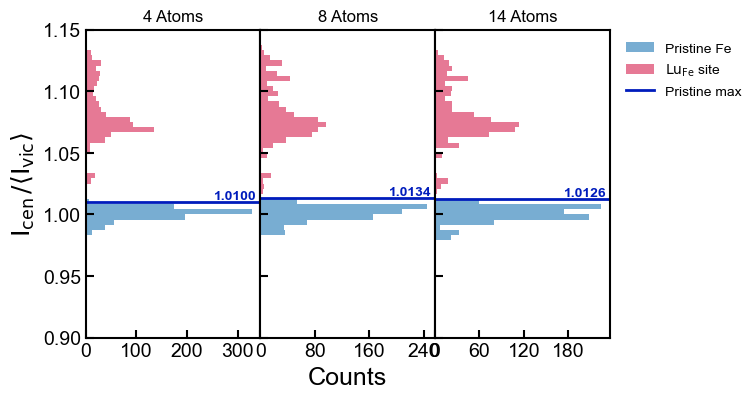

In [6]:
hist_min = 0.9
hist_max = 1.15
n_bins = 60
fig, axes = plt.subplots(1, len(configs), figsize=(8, 4), sharey=True)

for ax, name in zip(axes, configs):
    pristine = pristine_intensities[name]
    defect = lufe_metrics[name].ravel()
    defect = defect[np.isfinite(defect)]
    bins = np.linspace(hist_min, hist_max, n_bins + 1)
    ax.hist(pristine, bins=bins, color="#1f77b4", alpha=0.6, orientation="horizontal", label="Pristine Fe")
    ax.hist(defect, bins=bins, color="#D6204E", alpha=0.6, orientation="horizontal", label=r"$\mathrm{Lu}_{\mathrm{Fe}}$ site")
    ax.axhline(pristine.max(), color="#001cbc", linestyle="-", label="Pristine max", linewidth=2)
    transform = ax.get_yaxis_transform()
    ax.text(0.98, pristine.max(), f"{pristine.max():.4f}", transform=transform, ha="right", va="bottom", color="#001cbc", fontweight="bold")
    # ax.axhline(np.nanmean(defect), color="#9D0229", linestyle="--", label="LuFe mean")
    ax.set_title(name)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4, integer=True))
    ax.tick_params(direction="in", length=6)
    ax.set_ylim(hist_min, hist_max)

axes[1].set_xlabel("Counts")
axes[0].set_ylabel(r"$\mathrm{I_{cen}} \, / \langle \mathrm{I_{vic}} \rangle$")
handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)), frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(wspace=0, right=0.78)
plt.show()

#### Lu_Fe relaxation

### Experimental defect intensity outliers

In [7]:
from matplotlib.patches import Patch as LegendPatch

experimental_source = hs.load("../data/images/HAADF/HAADF_Buena.dm3")
experimental_signal = experimental_source.isig[20:2028, 200:1948]

# experimental_source = hs.load("../data/images/EELS/EEL SI 22 13/Integrated Shifted Spectrum Image adf.dm3")
# experimental_signal = experimental_source.isig[0:185, 20:235]

experimental_layout = grid_creator.detect_layout(experimental_signal)
experimental_grid = grid_creator.process(
    experimental_signal, layout=experimental_layout
)
experimental_intensities = intensity_analyzer.values(
    experimental_grid, metric=metric
)
experimental_relative = {
    name: intensity_analyzer.relative_vicinity(
        experimental_grid,
        offsets=offsets,
        metric=metric,
        values=experimental_intensities,
    )
    for name, offsets in configs.items()
}
experimental_fe_mask = experimental_grid.atom_type_mask("Fe")

#### Lu_Fe

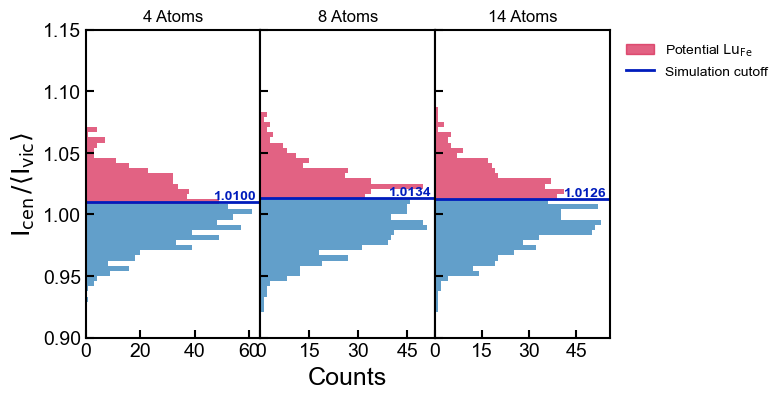

In [8]:
hist_min = 0.9
hist_max = 1.15
n_bins = 60
antisite_cutoffs = {
    name: values.max() for name, values in pristine_intensities.items()
}
higher_maps = {
    name: (values > antisite_cutoffs[name])
    & experimental_fe_mask
    & np.isfinite(values)
    for name, values in experimental_relative.items()
}
higher_map_combined = np.logical_and.reduce(list(higher_maps.values()))
np.save("LuFe_indicies.npy", np.argwhere(higher_map_combined))
valid_fe_sites_all_metrics = experimental_fe_mask & np.logical_and.reduce([
    np.isfinite(values) for values in experimental_relative.values()
])

fig, axes = plt.subplots(1, len(configs), figsize=(8, 4), sharey=True)

for ax, name in zip(axes, configs):
    cutoff = antisite_cutoffs[name]
    values = experimental_relative[name]
    values = values[experimental_fe_mask & np.isfinite(values)]
    counts, edges = np.histogram(
        values, bins=n_bins, range=(hist_min, hist_max)
    )
    centers = (edges[:-1] + edges[1:]) / 2
    colors = np.where(centers > cutoff, "#D6204E", "#1f77b4")
    ax.barh(centers, counts, height=np.diff(edges), color=colors, alpha=0.7)
    # ax.axhline(values.mean(), color="#001cbc", linestyle="--")
    ax.axhline(cutoff, color="#001cbc", linewidth=2)
    transform = ax.get_yaxis_transform()
    ax.text(0.98, cutoff, f"{cutoff:.4f}", transform=transform, ha="right", va="bottom", color="#001cbc", fontweight="bold")
    # ax.text(0.98, values.mean(), f"{values.mean():.4f}", transform=transform, ha="right", va="bottom", color="#001cbc")
    ax.set_title(name)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4, integer=True, prune="upper"))
    ax.tick_params(direction="in", length=6)
    ax.set_ylim(hist_min, hist_max)

legend = [
    LegendPatch(color="#D6204E", alpha=0.7, label=r"Potential $\mathrm{Lu}_{\mathrm{Fe}}$"),
    # LegendPatch(color="#1f77b4", alpha=0.7, label=r"Potential non-antisites"),
    Line2D([0], [0], color="#001cbc", linewidth=2, label="Simulation cutoff"),
]
axes[1].set_xlabel("Counts")
axes[0].set_ylabel(r"$\mathrm{I_{cen}} \, / \langle \mathrm{I_{vic}} \rangle$")
axes[-1].legend(handles=legend, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(wspace=0, right=0.78)
plt.show()

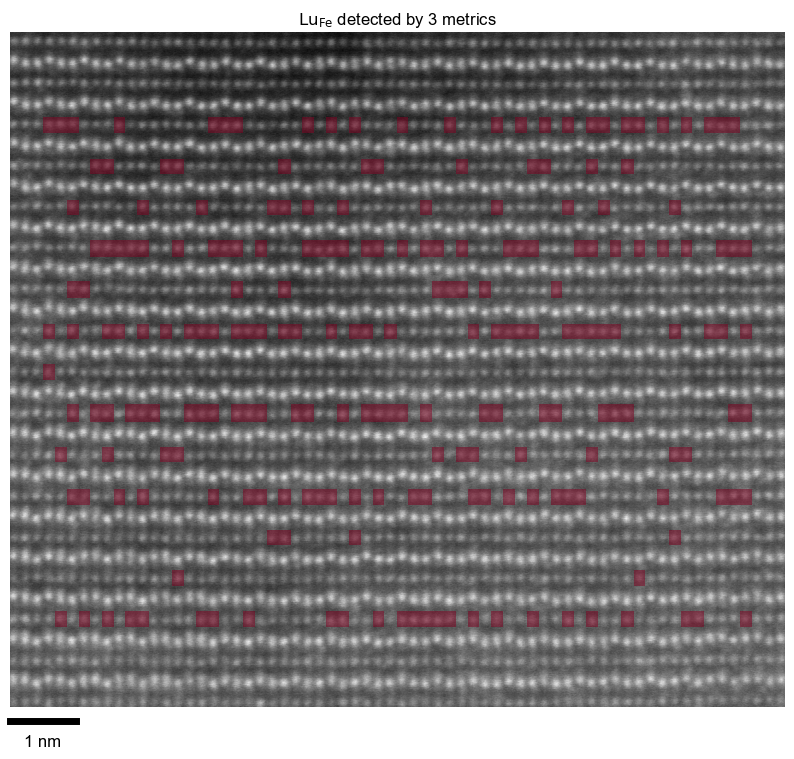

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '$\\mathrm{Lu}_{\\mathrm{Fe}}$ detected by 3 metrics'}>)

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
experimental_plotter = roi_tools.PatchGridPlotter(
    experimental_signal, experimental_grid, ax=ax
)
experimental_plotter.add_boolean_faces(
    higher_map_combined, color="#820021", alpha=0.5, linewidth=1
)
ax.set_title(r"$\mathrm{Lu}_{\mathrm{Fe}}$ detected by 3 metrics")
experimental_plotter.show(
    axis_on=False, scale_nm=1, scale_linewidth=5, scale_fontsize=12
)

In [10]:
detection_summary = pd.DataFrame({
    "Antisites detected by all 3 metrics": [
        np.count_nonzero(higher_map_combined)
    ],
    "Valid Fe sites for all 3 metrics": [
        np.count_nonzero(valid_fe_sites_all_metrics)
    ],
})
detection_summary

,Antisites detected by all 3 metrics,Valid Fe sites for all 3 metrics
0,220,780


#### V_Fe

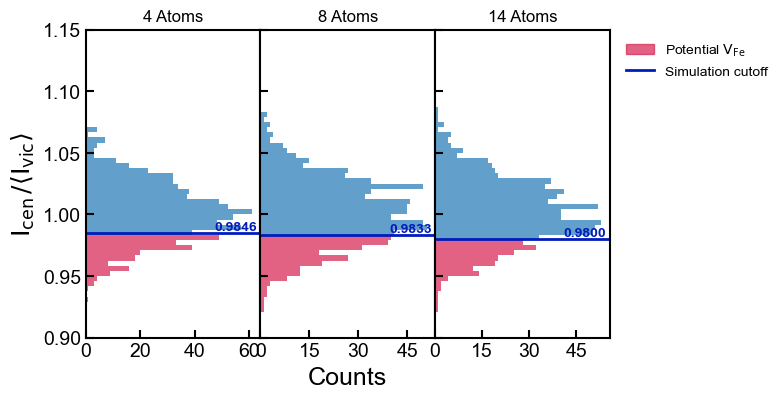

In [11]:
hist_min = 0.9
hist_max = 1.15
n_bins = 60
vacancy_cutoffs = {
    name: values.min() for name, values in pristine_intensities.items()
}
lower_maps = {
    name: (values < vacancy_cutoffs[name])
    & experimental_fe_mask
    & np.isfinite(values)
    for name, values in experimental_relative.items()
}
lower_map_combined = np.logical_and.reduce(list(lower_maps.values()))
np.save("VFe_indices.npy", np.argwhere(lower_map_combined))

fig, axes = plt.subplots(1, len(configs), figsize=(8, 4), sharey=True)

for ax, name in zip(axes, configs):
    cutoff = vacancy_cutoffs[name]
    values = experimental_relative[name]
    values = values[experimental_fe_mask & np.isfinite(values)]
    counts, edges = np.histogram(
        values, bins=n_bins, range=(hist_min, hist_max)
    )
    centers = (edges[:-1] + edges[1:]) / 2
    colors = np.where(centers < cutoff, "#D6204E", "#1f77b4")
    ax.barh(centers, counts, height=np.diff(edges), color=colors, alpha=0.7)
    # ax.axhline(values.mean(), color="#001cbc", linestyle="--")
    ax.axhline(cutoff, color="#001cbc", linewidth=2)
    transform = ax.get_yaxis_transform()
    ax.text(0.98, cutoff, f"{cutoff:.4f}", transform=transform, ha="right", va="bottom", color="#001cbc", fontweight="bold")
    # ax.text(0.98, values.mean(), f"{values.mean():.4f}", transform=transform, ha="right", va="bottom", color="#001cbc")
    ax.set_title(name)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4, integer=True, prune="upper"))
    ax.tick_params(direction="in", length=6)
    ax.set_ylim(hist_min, hist_max)

legend = [
    LegendPatch(color="#D6204E", alpha=0.7, label=r"Potential $\mathrm{V}_{\mathrm{Fe}}$"),
    # LegendPatch(color="#1f77b4", alpha=0.7, label="Potential non-vacancies"),
    Line2D([0], [0], color="#001cbc", linewidth=2, label="Simulation cutoff"),
    # Line2D([0], [0], color="#001cbc", linestyle="--", label="Mean"),
]
axes[1].set_xlabel("Counts")
axes[0].set_ylabel(r"$\mathrm{I_{cen}} \, / \langle \mathrm{I_{vic}} \rangle$")
axes[-1].legend(handles=legend, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(wspace=0, right=0.78)
plt.show()

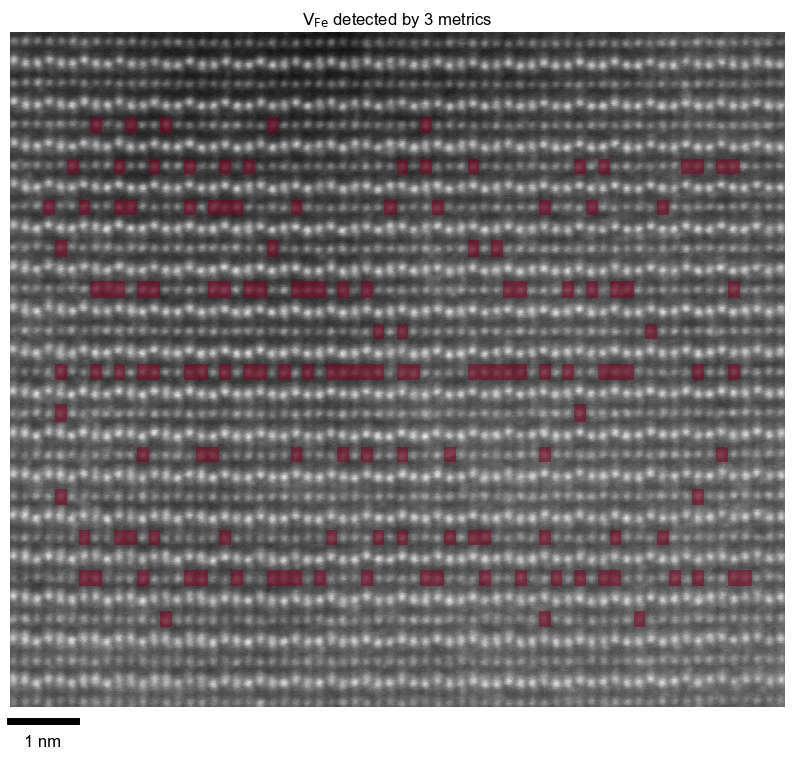

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '$\\mathrm{V}_{\\mathrm{Fe}}$ detected by 3 metrics'}>)

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
experimental_plotter = roi_tools.PatchGridPlotter(
    experimental_signal, experimental_grid, ax=ax
)
experimental_plotter.add_boolean_faces(
    lower_map_combined, color="#820021", alpha=0.5, linewidth=1
)
ax.set_title(r"$\mathrm{V}_{\mathrm{Fe}}$ detected by 3 metrics")
experimental_plotter.show(
    axis_on=False, scale_nm=1, scale_linewidth=5, scale_fontsize=12
)

In [13]:
vacancy_detection_summary = pd.DataFrame({
    "Vacancies detected by all 3 metrics": [
        np.count_nonzero(lower_map_combined)
    ],
    "Valid Fe sites for all 3 metrics": [
        np.count_nonzero(valid_fe_sites_all_metrics)
    ],
})
vacancy_detection_summary

,Vacancies detected by all 3 metrics,Valid Fe sites for all 3 metrics
0,147,780


In [14]:
def clustered_defect_sites(defect_map):
    has_horizontal_neighbor = np.zeros_like(defect_map, dtype=bool)
    has_horizontal_neighbor[1:, :] |= defect_map[:-1, :]
    has_horizontal_neighbor[:-1, :] |= defect_map[1:, :]
    return defect_map & has_horizontal_neighbor


clustered_lufe_sites = clustered_defect_sites(higher_map_combined)
clustered_vfe_sites = clustered_defect_sites(lower_map_combined)
clustered_defect_summary = pd.DataFrame({
    "Defect": [r"$\mathrm{Lu}_{\mathrm{Fe}}$", r"$\mathrm{V}_{\mathrm{Fe}}$"],
    "Detected defects with a left or right defect neighbor": [
        np.count_nonzero(clustered_lufe_sites),
        np.count_nonzero(clustered_vfe_sites),
    ],
})
clustered_defect_summary

,Defect,Detected defects with a left or right defect neighbor
0,$\mathrm{Lu}_{\mathrm{Fe}}$,139
1,$\mathrm{V}_{\mathrm{Fe}}$,65
